In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [2]:
# GPU 사용 가능 여부 확인
print(f"GPU 사용 가능 여부: {torch.cuda.is_available()}")

# 사용 가능한 GPU 개수 및 이름 확인
if torch.cuda.is_available():
    print(f"GPU 개수: {torch.cuda.device_count()}")
    print(f"현재 GPU 이름: {torch.cuda.get_device_name(0)}")

GPU 사용 가능 여부: True
GPU 개수: 1
현재 GPU 이름: NVIDIA TITAN Xp


In [ ]:
# 하이퍼파라미터 설정
BATCH_SIZE=32
EPOCHS=30
LR =0.001 # Optimizer = Adam 
NUM_CLASSES =2
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
import glob 
import os 

# 경로 지정 
root='./'
image_folder_path = os.path.join(root, 'product_images') 

# images 폴더가 없으면 생성(이미 존재하면 건너뜀)
if not os.path.exists(image_folder_path):
    os.makedirs(image_folder_path)

import kaggle
kaggle.api.dataset_download_files('ravirajsinh45/real-life-industrial-dataset-of-casting-product', path=image_folder_path, unzip=True)

print(image_folder_path)
print(glob.glob(image_folder_path+'/*')) 

Dataset URL: https://www.kaggle.com/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product
./product_images
['./product_images/casting_data', './product_images/casting_512x512']


In [5]:
TRAIN_DIR = os.path.join(image_folder_path, "casting_data", "casting_data","train")
TEST_DIR = os.path.join(image_folder_path, "casting_data", "casting_data", "test")

print("Train 경로:", TRAIN_DIR)
print("TEST 경로:", TEST_DIR)

Train 경로: ./product_images/casting_data/casting_data/train
TEST 경로: ./product_images/casting_data/casting_data/test


In [6]:
# VGGNet 19-layer (VGG-19) 정의 
class VGG19(nn.Module):
    def __init__(self, num_classes=2):
        super(VGG19, self).__init__()

        # Convolution + ReLU layers (3x3 convolution, padding=1)
        # nn.Sequential는 "레이어를 순서대로 담는 상자"이다.

        self.features = nn.Sequential(
            # Block 1 : 2 conv layers + maxpool
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 2: 2 conv layers + maxpool
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 3: 4 conv layers + maxpool
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 4 : 4 conv layers + maxpool
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 5 : 4 conv layers + maxpool
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        # Fully Connected layers
        self.classifier = nn.Sequential(
            nn.Linear(512*7*7, 4096), # 입력 크기 : 마지막 feature map 7x7
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, num_classes)
        )

    def forward(self,x):
        x=self.features(x) # Convolution & Pooling
        x=x.view(x.size(0),-1) # Flatten
        x=self.classifier(x) # Fully Connected Network
        return x
    
model = VGG19(num_classes=2).to(DEVICE)
print(f"Using device : {DEVICE}")
# print(model)

Using device : cuda


In [7]:
# # 데이터 전처리 & DataLoader
# train_transform = transforms.Compose([
#     transforms.Resize((224,224)),
#     transforms.RandomHorizontalFlip(), # 좌우 반전(데이터 증강)
#     transforms.RandomRotation(10), # 10도 회전(데이터 증강)
#     transforms.ToTensor(), 
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), # ImageNet 기준 정규화
# ])

# 데이터 전처리 & DataLoader
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(), # 좌우 반전(데이터 증강)
    transforms.RandomVerticalFlip(), # 상하 반전 추가
    transforms.RandomRotation(10), # 10도 회전(데이터 증강)
    transforms.RandomAffine( # Height/Width Shift 추가
        degrees=0,
        translate=(0.1, 0.1)                    
    ),
    transforms.ToTensor(), 
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), # ImageNet 기준 정규화
    transforms.Lambda(
        lambda x: x + 0.01 * torch.randn_like(x)  # Gaussian Noise 추가
    ),
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size = BATCH_SIZE, shuffle=False)

print(f"클래스 : {train_dataset.classes}")
print(f"학습 데이터 수: {len(train_dataset)}")
print(f"테스트 데이터 수: {len(test_dataset)}")

클래스 : ['def_front', 'ok_front']
학습 데이터 수: 6633
테스트 데이터 수: 715


In [8]:
# loss 함수 & optimizer 설정 
criterion = nn.CrossEntropyLoss() # softmax 내장 
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# LR Scheduler : val_loss가 5 epoch 동안 개선이 없으면 LR을 절반으로 줄임 
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6 
)

# Early Stopping 설정 
patience = 10 # 10 epoch 동안 개선 없으면 학습 중단 
best_val_loss = float('inf')
counter=0

# train 
def train(model, loader, criterion, optimizer):
    model.train() # 학습 모드
    total_loss, correct, total = 0,0,0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad() # gradient 초기화 
        outputs=model(images)
        loss=criterion(outputs, labels)
        loss.backward() 

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # 기울기 확 커지는거 방지

        optimizer.step() # 가중치 업데이트 

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), 100. * correct / total

In [9]:
# test
def test(model, loader, criterion):
    model.eval() # 평가모드
    total_loss, correct, total = 0,0,0

    with torch.no_grad(): # gradient 계산 비활성화
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    return total_loss / len(loader), 100. * correct / total

In [10]:
# 학습 실행 
train_losses, train_accs = [], []
test_losses, test_accs = [], []

for epoch in range(1, EPOCHS +1):
    train_loss, train_acc = train(model, train_loader, criterion, optimizer)
    test_loss, test_acc = test(model, test_loader, criterion)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_losses.append(test_loss)
    test_accs.append(test_acc)

    # LR Scheduler - val_loss 기준으로 LR 조정
    scheduler.step(test_loss)

    print(f"\nEpoch [{epoch:02d}/{EPOCHS}]")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Test  Loss: {test_loss:.4f} | Test  Acc: {test_acc:.2f}%")
    print(f"  LR: {optimizer.param_groups[0]['lr']:.6f}")
    print("-" * 50)
    
    # Early Stopping 
    if test_loss < best_val_loss:
        best_val_loss = test_loss
        counter=0
        torch.save(model.state_dict(), "vgg19_best.pth") # 가장 좋은 모델 저장
        print(f" Best 모델 저장! (val_loss: {best_val_loss:.4f})")
    else:
        counter +=1
        print(f"Early Stopping 카운터: {counter}/{patience}")
        if counter >= patience:
            print(f"\n Early Stopping! {epoch} epoch에서 학습 중단")
            break

# 최종 성능 출력 
# Best 모델 불러오기 
model.load_state_dict(torch.load("vgg19_best.pth"))

# Best 모델로 최종 평가 
final_loss, final_acc = test(model, test_loader, criterion)

print("\n" + "=" * 50)
print("           최종 성능 결과")
print("=" * 50)
print(f"  Best Val Loss : {best_val_loss:.4f}")
print(f"  Final Test Loss : {final_loss:.4f}")
print(f"  Final Test Acc  : {final_acc:.2f}%")
print(f"  총 학습 Epoch  : {len(train_losses)}")
print(f"  Best Epoch     : {test_losses.index(min(test_losses)) + 1}")
print("=" * 50)


Epoch [01/30]
  Train Loss: 2.2736 | Train Acc: 77.08%
  Test  Loss: 1.4163 | Test  Acc: 71.47%
  LR: 0.001000
--------------------------------------------------
 Best 모델 저장! (val_loss: 1.4163)

Epoch [02/30]
  Train Loss: 0.4577 | Train Acc: 84.19%
  Test  Loss: 2.0018 | Test  Acc: 68.95%
  LR: 0.001000
--------------------------------------------------
Early Stopping 카운터: 1/10

Epoch [03/30]
  Train Loss: 0.3518 | Train Acc: 88.77%
  Test  Loss: 0.2930 | Test  Acc: 87.41%
  LR: 0.001000
--------------------------------------------------
 Best 모델 저장! (val_loss: 0.2930)

Epoch [04/30]
  Train Loss: 0.2777 | Train Acc: 90.71%
  Test  Loss: 0.2791 | Test  Acc: 87.97%
  LR: 0.001000
--------------------------------------------------
 Best 모델 저장! (val_loss: 0.2791)

Epoch [05/30]
  Train Loss: 0.2054 | Train Acc: 93.94%
  Test  Loss: 3.8890 | Test  Acc: 64.90%
  LR: 0.001000
--------------------------------------------------
Early Stopping 카운터: 1/10

Epoch [06/30]
  Train Loss: 0.1950 | T

/tmp/ipykernel_223521/4076128724.py:38: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("vgg19_best.pth"))



           최종 성능 결과
  Best Val Loss : 0.0394
  Final Test Loss : 0.0394
  Final Test Acc  : 99.30%
  총 학습 Epoch  : 30
  Best Epoch     : 22


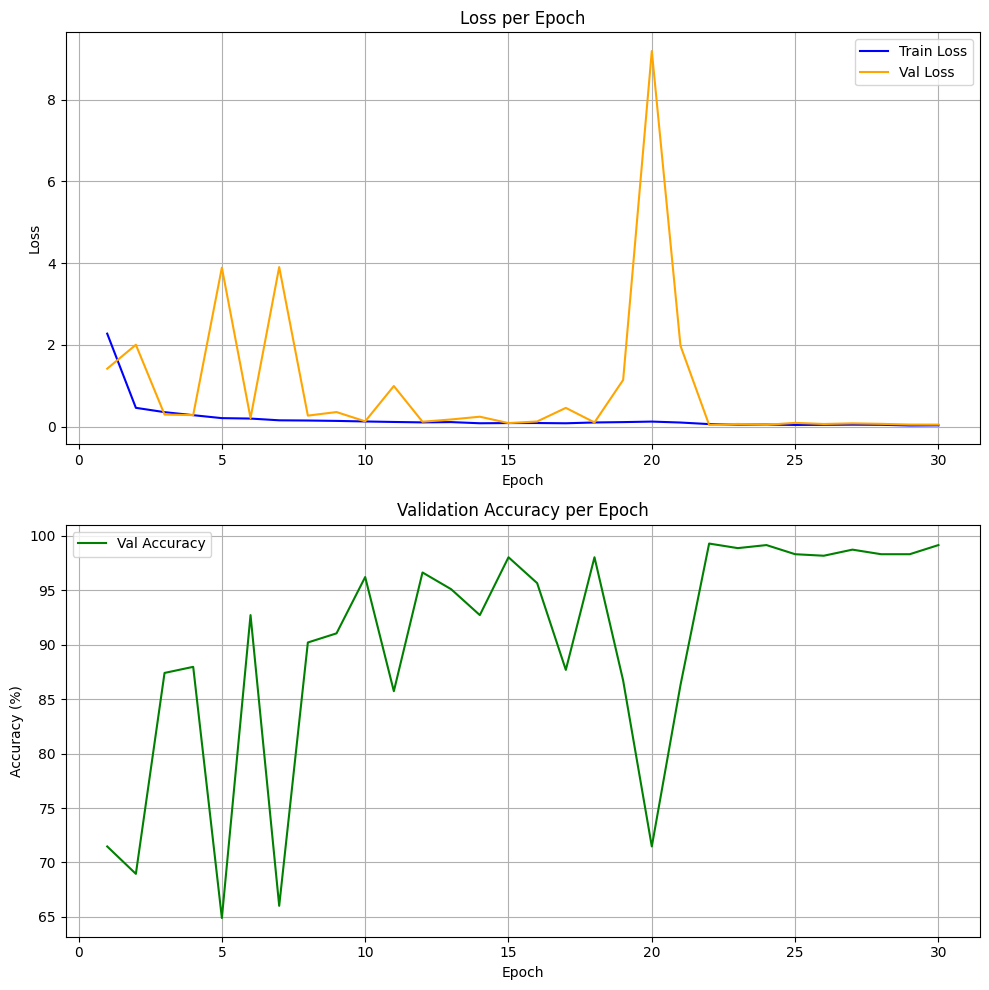

In [11]:
epochs_range = range(1, len(train_losses) + 1)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

# Loss 그래프
ax1.plot(epochs_range, train_losses, label="Train Loss", color='blue')
ax1.plot(epochs_range, test_losses,  label="Val Loss",   color='orange')
ax1.set_title("Loss per Epoch")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True)

# Accuracy 그래프
ax2.plot(epochs_range, test_accs, label="Val Accuracy", color='green')
ax2.set_title("Validation Accuracy per Epoch")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig("vgg19_result.png", dpi=150)
plt.show()

In [12]:
model.load_state_dict(torch.load("vgg19_best.pth"))
model.eval()
wrong = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        _, predicted = outputs.max(1)
        wrong += (predicted != labels).sum().item()

print(f"틀린 이미지 수: {wrong}개 / {len(test_dataset)}개")

/tmp/ipykernel_223521/2578206704.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("vgg19_best.pth"))


틀린 이미지 수: 5개 / 715개
